# Task
Train and save a machine learning model using the 'HI-Small_Trans.csv' dataset.

## Upload Dataset

### Subtask:
Upload the 'HI-Small_Trans.csv' dataset from your local machine using `files.upload()`.


**Reasoning**:
The subtask is to upload a CSV file using `google.colab.files.upload()`. This requires importing `files` from `google.colab` and then calling the `upload()` method.



In [1]:
from google.colab import files

print("Please upload the 'HI-Small_Trans.csv' file when prompted.")
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Please upload the 'HI-Small_Trans.csv' file when prompted.


Saving HI-Small_Trans.csv to HI-Small_Trans.csv
User uploaded file "HI-Small_Trans.csv" with length 475664283 bytes


In [20]:
from google.colab import files

# The filename was defined in the previous step
model_filename = 'random_forest_model.pkl'

# Download the model file
files.download(model_filename)

print(f"'{model_filename}' downloaded successfully.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'random_forest_model.pkl' downloaded successfully.


## Load Data

### Subtask:
Load the uploaded CSV file into a pandas DataFrame for further processing.


**Reasoning**:
To load the CSV file, I need to import the pandas library first. Then I will use pandas' read_csv function to load the 'HI-Small_Trans.csv' file into a DataFrame.



In [2]:
import pandas as pd

# The filename was captured from the previous step
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)
print(f"Successfully loaded '{file_name}' into a DataFrame.")
df.head()

Successfully loaded 'HI-Small_Trans.csv' into a DataFrame.


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


## Initial Data Exploration and Visualization

### Subtask:
Perform an initial exploration of the dataset, including displaying the head, checking data types, identifying missing values, and generating basic visualizations (e.g., distribution plots, count plots) to understand the data's structure and potential relationships.


**Reasoning**:
The subtask requires an initial data exploration, including displaying the head, checking data types, identifying missing values, and generating descriptive statistics. I will combine these steps into a single code block for efficiency.



In [3]:
print("Displaying the first 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Info:")
df.info()

print("\nDescriptive Statistics for Numerical Columns:")
print(df.describe())

print("\nMissing values in each column:")
print(df.isnull().sum())

Displaying the first 5 rows of the DataFrame:
          Timestamp  From Bank    Account  To Bank  Account.1  \
0  2022/09/01 00:20         10  8000EBD30       10  8000EBD30   
1  2022/09/01 00:20       3208  8000F4580        1  8000F5340   
2  2022/09/01 00:00       3209  8000F4670     3209  8000F4670   
3  2022/09/01 00:02         12  8000F5030       12  8000F5030   
4  2022/09/01 00:06         10  8000F5200       10  8000F5200   

   Amount Received Receiving Currency  Amount Paid Payment Currency  \
0          3697.34          US Dollar      3697.34        US Dollar   
1             0.01          US Dollar         0.01        US Dollar   
2         14675.57          US Dollar     14675.57        US Dollar   
3          2806.97          US Dollar      2806.97        US Dollar   
4         36682.97          US Dollar     36682.97        US Dollar   

  Payment Format  Is Laundering  
0   Reinvestment              0  
1         Cheque              0  
2   Reinvestment              0  


**Reasoning**:
I need to import the `matplotlib.pyplot` and `seaborn` libraries to create the required visualizations. This step addresses the instruction to import these libraries before generating plots.



In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Matplotlib and Seaborn imported successfully for visualization.")

Matplotlib and Seaborn imported successfully for visualization.


**Reasoning**:
As requested in the subtask, I will now create a count plot for the 'Is Laundering' column to visualize its distribution. This will provide insight into the balance of the target variable.



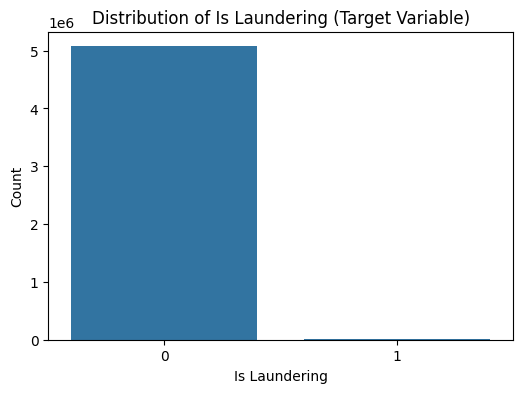

Count plot for 'Is Laundering' generated.


In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Is Laundering', data=df)
plt.title('Distribution of Is Laundering (Target Variable)')
plt.xlabel('Is Laundering')
plt.ylabel('Count')
plt.show()
print("Count plot for 'Is Laundering' generated.")

**Reasoning**:
I will create distribution plots for the numerical columns 'Amount Received' and 'Amount Paid' using `seaborn.histplot`. Given the wide range of values indicated by `df.describe()`, applying a logarithmic scale to the x-axis will help visualize the distribution more effectively.



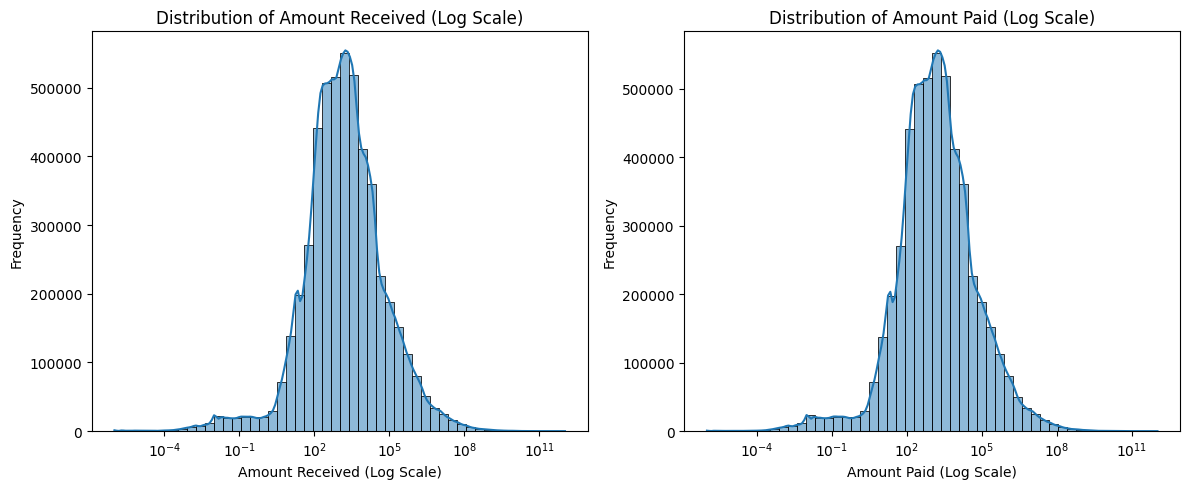

Distribution plots for 'Amount Received' and 'Amount Paid' generated.


In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Amount Received'], bins=50, kde=True, log_scale=True)
plt.title('Distribution of Amount Received (Log Scale)')
plt.xlabel('Amount Received (Log Scale)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['Amount Paid'], bins=50, kde=True, log_scale=True)
plt.title('Distribution of Amount Paid (Log Scale)')
plt.xlabel('Amount Paid (Log Scale)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()
print("Distribution plots for 'Amount Received' and 'Amount Paid' generated.")

**Reasoning**:
As requested in the subtask, I will now create count plots for the categorical columns: 'Receiving Currency', 'Payment Currency', and 'Payment Format' to visualize their distributions.



/tmp/ipython-input-2318383211.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Receiving Currency', data=df, palette='viridis')
/tmp/ipython-input-2318383211.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Payment Currency', data=df, palette='viridis')
/tmp/ipython-input-2318383211.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Payment Format', data=df, palette='viridis')


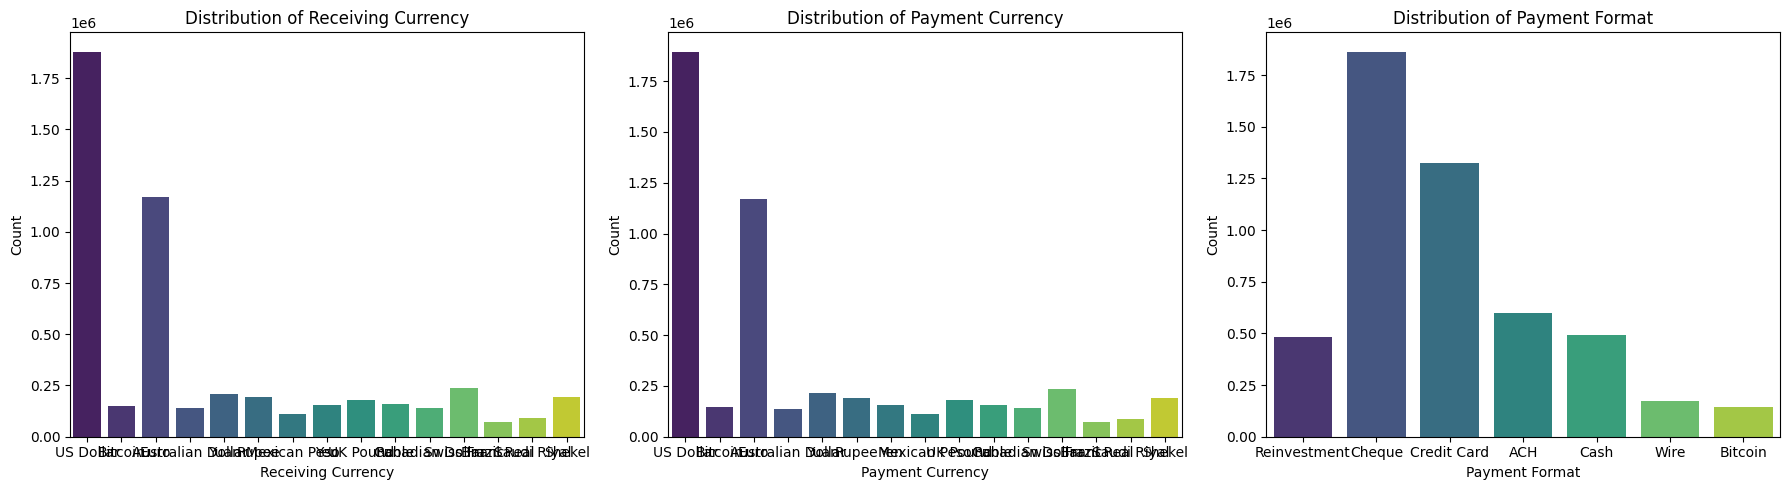

Count plots for 'Receiving Currency', 'Payment Currency', and 'Payment Format' generated.


In [7]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(x='Receiving Currency', data=df, palette='viridis')
plt.title('Distribution of Receiving Currency')
plt.xlabel('Receiving Currency')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
sns.countplot(x='Payment Currency', data=df, palette='viridis')
plt.title('Distribution of Payment Currency')
plt.xlabel('Payment Currency')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
sns.countplot(x='Payment Format', data=df, palette='viridis')
plt.title('Distribution of Payment Format')
plt.xlabel('Payment Format')
plt.ylabel('Count')

plt.tight_layout()
plt.show()
print("Count plots for 'Receiving Currency', 'Payment Currency', and 'Payment Format' generated.")

**Reasoning**:
The previous code generated `FutureWarning` because `palette` was used without assigning a `hue` variable. To comply with future seaborn versions and eliminate the warning, I will explicitly set `hue` to the same column as `x` and set `legend=False` for each count plot.



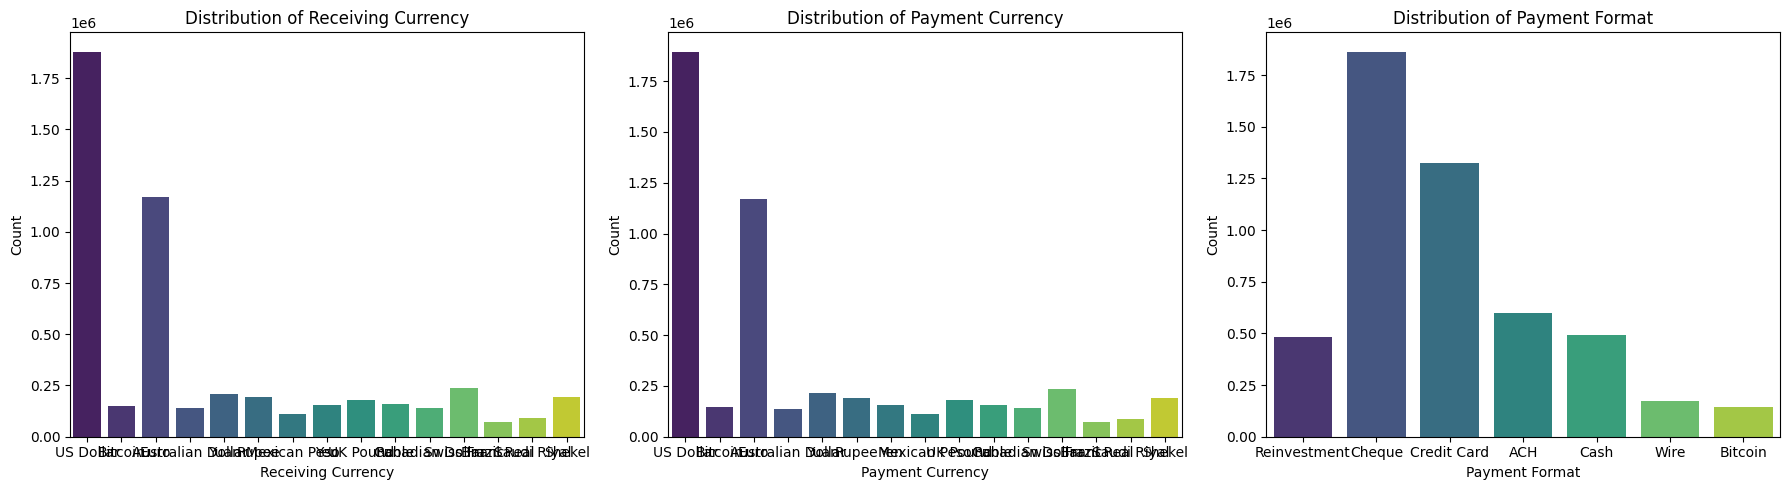

Count plots for 'Receiving Currency', 'Payment Currency', and 'Payment Format' generated.


In [8]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(x='Receiving Currency', data=df, hue='Receiving Currency', palette='viridis', legend=False)
plt.title('Distribution of Receiving Currency')
plt.xlabel('Receiving Currency')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
sns.countplot(x='Payment Currency', data=df, hue='Payment Currency', palette='viridis', legend=False)
plt.title('Distribution of Payment Currency')
plt.xlabel('Payment Currency')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
sns.countplot(x='Payment Format', data=df, hue='Payment Format', palette='viridis', legend=False)
plt.title('Distribution of Payment Format')
plt.xlabel('Payment Format')
plt.ylabel('Count')

plt.tight_layout()
plt.show()
print("Count plots for 'Receiving Currency', 'Payment Currency', and 'Payment Format' generated.")

## Data Preprocessing

### Subtask:
Clean the data by dropping irrelevant identifier columns, converting 'Timestamp' to datetime objects, encoding categorical features (e.g., One-Hot Encoding), and scaling numerical features (e.g., StandardScaler).


**Reasoning**:
The first step in data cleaning is to drop irrelevant identifier columns and convert the 'Timestamp' column to a datetime object, as specified in the instructions. This prepares the data for further feature engineering and model training.



In [9]:
print("Original DataFrame shape:", df.shape)

# 1. Drop irrelevant identifier columns
df = df.drop(columns=['Account', 'Account.1'])
print("Dropped 'Account' and 'Account.1' columns. New DataFrame shape:", df.shape)

# 2. Convert 'Timestamp' to datetime objects
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print("Converted 'Timestamp' column to datetime objects.")
print(df['Timestamp'].head())
print(df.info())

Original DataFrame shape: (5078345, 11)
Dropped 'Account' and 'Account.1' columns. New DataFrame shape: (5078345, 9)
Converted 'Timestamp' column to datetime objects.
0   2022-09-01 00:20:00
1   2022-09-01 00:20:00
2   2022-09-01 00:00:00
3   2022-09-01 00:02:00
4   2022-09-01 00:06:00
Name: Timestamp, dtype: datetime64[ns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 9 columns):
 #   Column              Dtype         
---  ------              -----         
 0   Timestamp           datetime64[ns]
 1   From Bank           int64         
 2   To Bank             int64         
 3   Amount Received     float64       
 4   Receiving Currency  object        
 5   Amount Paid         float64       
 6   Payment Currency    object        
 7   Payment Format      object        
 8   Is Laundering       int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 348.7+ MB
None


**Reasoning**:
The next step in data preprocessing is to identify categorical columns and apply one-hot encoding to them as specified in the instructions. This converts categorical features into a numerical format suitable for machine learning models.



In [10]:
print("Original DataFrame shape before one-hot encoding:", df.shape)

# 3. Identify categorical columns and apply one-hot encoding
categorical_cols = ['Receiving Currency', 'Payment Currency', 'Payment Format']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Categorical columns one-hot encoded. New DataFrame shape:", df_encoded.shape)
print(df_encoded.head())

Original DataFrame shape before one-hot encoding: (5078345, 9)
Categorical columns one-hot encoded. New DataFrame shape: (5078345, 40)
            Timestamp  From Bank  To Bank  Amount Received  Amount Paid  \
0 2022-09-01 00:20:00         10       10          3697.34      3697.34   
1 2022-09-01 00:20:00       3208        1             0.01         0.01   
2 2022-09-01 00:00:00       3209     3209         14675.57     14675.57   
3 2022-09-01 00:02:00         12       12          2806.97      2806.97   
4 2022-09-01 00:06:00         10       10         36682.97     36682.97   

   Is Laundering  Receiving Currency_Bitcoin  Receiving Currency_Brazil Real  \
0              0                       False                           False   
1              0                       False                           False   
2              0                       False                           False   
3              0                       False                           False   
4             

**Reasoning**:
The final step in data preprocessing, as per the instructions, is to scale the numerical features. I will identify the specified numerical columns ('From Bank', 'To Bank', 'Amount Received', and 'Amount Paid'), import `StandardScaler` from `sklearn.preprocessing`, and then fit-transform these columns to normalize their ranges. The original columns will be replaced with their scaled versions.



In [11]:
from sklearn.preprocessing import StandardScaler

print("DataFrame shape before scaling:", df_encoded.shape)

# 4. Identify numerical columns and apply StandardScaler
numerical_cols = ['From Bank', 'To Bank', 'Amount Received', 'Amount Paid']

scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print("Numerical columns scaled. Displaying head of scaled columns:")
print(df_encoded[numerical_cols].head())
print(df_encoded.info())

DataFrame shape before scaling: (5078345, 40)
Numerical columns scaled. Displaying head of scaled columns:
   From Bank   To Bank  Amount Received  Amount Paid
0  -0.559166 -0.781689        -0.005770    -0.005180
1  -0.520054 -0.781796        -0.005774    -0.005184
2  -0.520042 -0.743648        -0.005760    -0.005168
3  -0.559142 -0.781665        -0.005771    -0.005181
4  -0.559166 -0.781689        -0.005739    -0.005142
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 40 columns):
 #   Column                              Dtype         
---  ------                              -----         
 0   Timestamp                           datetime64[ns]
 1   From Bank                           float64       
 2   To Bank                             float64       
 3   Amount Received                     float64       
 4   Amount Paid                         float64       
 5   Is Laundering                       int64         
 6   Receiving

## Feature Engineering

### Subtask:
Create new features from existing ones, such as extracting time-based features from the 'Timestamp' column and potentially deriving features from transaction amounts.


**Reasoning**:
The subtask requires extracting time-based features ('hour' and 'day of week') from the 'Timestamp' column, calculating the difference between transaction amounts, and then dropping the original 'Timestamp' column. These operations will be performed on the `df_encoded` DataFrame.



In [12]:
print("DataFrame shape before feature engineering:", df_encoded.shape)

# 1. Extract 'hour' and 'day of week' from 'Timestamp'
df_encoded['Hour'] = df_encoded['Timestamp'].dt.hour
df_encoded['DayOfWeek'] = df_encoded['Timestamp'].dt.dayofweek
print("Extracted 'Hour' and 'DayOfWeek' from 'Timestamp'.")

# 2. Calculate 'Amount_Difference'
df_encoded['Amount_Difference'] = df_encoded['Amount Received'] - df_encoded['Amount Paid']
print("Calculated 'Amount_Difference'.")

# 3. Drop the original 'Timestamp' column
df_encoded = df_encoded.drop(columns=['Timestamp'])
print("Dropped 'Timestamp' column. New DataFrame shape:", df_encoded.shape)

# 4. Print the head of the updated DataFrame
print("\nHead of updated DataFrame with new features:")
print(df_encoded.head())

DataFrame shape before feature engineering: (5078345, 40)
Extracted 'Hour' and 'DayOfWeek' from 'Timestamp'.
Calculated 'Amount_Difference'.
Dropped 'Timestamp' column. New DataFrame shape: (5078345, 42)

Head of updated DataFrame with new features:
   From Bank   To Bank  Amount Received  Amount Paid  Is Laundering  \
0  -0.559166 -0.781689        -0.005770    -0.005180              0   
1  -0.520054 -0.781796        -0.005774    -0.005184              0   
2  -0.520042 -0.743648        -0.005760    -0.005168              0   
3  -0.559142 -0.781665        -0.005771    -0.005181              0   
4  -0.559166 -0.781689        -0.005739    -0.005142              0   

   Receiving Currency_Bitcoin  Receiving Currency_Brazil Real  \
0                       False                           False   
1                       False                           False   
2                       False                           False   
3                       False                           False  

## Feature Selection

### Subtask:
Select the most relevant features for model training using techniques like correlation analysis, statistical tests, or feature importance from tree-based models.


**Reasoning**:
The first step in feature selection is to separate the features (X) from the target variable (y), 'Is Laundering', as specified in the instructions. This prepares the data for training a Random Forest model to determine feature importance.



In [13]:
print("Original DataFrame shape:", df_encoded.shape)

# Separate features (X) and target variable (y)
X = df_encoded.drop(columns=['Is Laundering'])
y = df_encoded['Is Laundering']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("First 5 rows of features (X):")
print(X.head())
print("First 5 rows of target (y):")
print(y.head())

Original DataFrame shape: (5078345, 42)
Shape of features (X): (5078345, 41)
Shape of target (y): (5078345,)
First 5 rows of features (X):
   From Bank   To Bank  Amount Received  Amount Paid  \
0  -0.559166 -0.781689        -0.005770    -0.005180   
1  -0.520054 -0.781796        -0.005774    -0.005184   
2  -0.520042 -0.743648        -0.005760    -0.005168   
3  -0.559142 -0.781665        -0.005771    -0.005181   
4  -0.559166 -0.781689        -0.005739    -0.005142   

   Receiving Currency_Bitcoin  Receiving Currency_Brazil Real  \
0                       False                           False   
1                       False                           False   
2                       False                           False   
3                       False                           False   
4                       False                           False   

   Receiving Currency_Canadian Dollar  Receiving Currency_Euro  \
0                               False                    False   
1

**Reasoning**:
I need to import `RandomForestClassifier`, initialize and train it on the features `X` and target `y` to calculate feature importances, then extract and display these importances as a sorted Series.



In [14]:
from sklearn.ensemble import RandomForestClassifier

print("Initializing RandomForestClassifier...")
# Initialize RandomForestClassifier
# Using a smaller n_estimators for quicker calculation for feature importance due to large dataset
# class_weight='balanced' is used to handle the class imbalance in 'Is Laundering'
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced', n_jobs=-1)

print("Training RandomForestClassifier to determine feature importances...")
# Train the model
rf_model.fit(X, y)

print("Extracting feature importances...")
# Extract feature importances
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Sort feature importances in descending order
sorted_feature_importances = feature_importances.sort_values(ascending=False)

# Display the top N most important features
N = 20 # You can adjust N to see more or fewer top features
print(f"\nTop {N} Feature Importances:")
print(sorted_feature_importances.head(N))


Initializing RandomForestClassifier...
Training RandomForestClassifier to determine feature importances...
Extracting feature importances...

Top 20 Feature Importances:
Payment Format_Cheque             0.161847
Payment Format_Credit Card        0.120684
Amount_Difference                 0.117160
Amount Received                   0.112381
From Bank                         0.097361
Amount Paid                       0.079644
To Bank                           0.054452
Hour                              0.049195
Payment Format_Cash               0.044888
Payment Format_Reinvestment       0.044691
DayOfWeek                         0.039712
Payment Format_Wire               0.020078
Payment Currency_US Dollar        0.005103
Receiving Currency_US Dollar      0.004918
Payment Currency_Euro             0.004429
Receiving Currency_Euro           0.004029
Payment Currency_Saudi Riyal      0.003727
Receiving Currency_Saudi Riyal    0.003111
Payment Currency_Yuan             0.002288
Receiving Cur

**Reasoning**:
Based on the calculated feature importances, I will select the top N features (where N is the number of features displayed previously) to create a new DataFrame containing only these most relevant features along with the target variable 'Is Laundering'. This fulfills the final instruction of the subtask.



In [15]:
print("Original DataFrame shape:", df_encoded.shape)

# Select the top N feature names based on the sorted importances
# N was set to 20 in the previous step
top_features = sorted_feature_importances.head(N).index.tolist()

# Create a new DataFrame with only the selected features and the target variable 'Is Laundering'
df_selected_features = df_encoded[top_features + ['Is Laundering']]

print(f"Created 'df_selected_features' with {len(top_features)} features and the target variable.")
print("New DataFrame shape:", df_selected_features.shape)
print("First 5 rows of df_selected_features:")
print(df_selected_features.head())

Original DataFrame shape: (5078345, 42)
Created 'df_selected_features' with 20 features and the target variable.
New DataFrame shape: (5078345, 21)
First 5 rows of df_selected_features:
   Payment Format_Cheque  Payment Format_Credit Card  Amount_Difference  \
0                  False                       False          -0.000590   
1                   True                       False          -0.000590   
2                  False                       False          -0.000592   
3                  False                       False          -0.000590   
4                  False                       False          -0.000596   

   Amount Received  From Bank  Amount Paid   To Bank  Hour  \
0        -0.005770  -0.559166    -0.005180 -0.781689     0   
1        -0.005774  -0.520054    -0.005184 -0.781796     0   
2        -0.005760  -0.520042    -0.005168 -0.743648     0   
3        -0.005771  -0.559142    -0.005181 -0.781665     0   
4        -0.005739  -0.559166    -0.005142 -0.781689 

## Train Machine Learning Model

### Subtask:
Split the preprocessed data into training and testing sets, select an appropriate machine learning model, and train it on the training data.


**Reasoning**:
The first step is to separate the features (X) from the target variable (y) from the `df_selected_features` DataFrame, as specified in the instructions. This prepares the data for splitting into training and testing sets.



In [16]:
print("Original df_selected_features shape:", df_selected_features.shape)

# 1. Separate features (X) from target variable (y)
X = df_selected_features.drop(columns=['Is Laundering'])
y = df_selected_features['Is Laundering']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("First 5 rows of features (X):")
print(X.head())
print("First 5 rows of target (y):")
print(y.head())

Original df_selected_features shape: (5078345, 21)
Shape of features (X): (5078345, 20)
Shape of target (y): (5078345,)
First 5 rows of features (X):
   Payment Format_Cheque  Payment Format_Credit Card  Amount_Difference  \
0                  False                       False          -0.000590   
1                   True                       False          -0.000590   
2                  False                       False          -0.000592   
3                  False                       False          -0.000590   
4                  False                       False          -0.000596   

   Amount Received  From Bank  Amount Paid   To Bank  Hour  \
0        -0.005770  -0.559166    -0.005180 -0.781689     0   
1        -0.005774  -0.520054    -0.005184 -0.781796     0   
2        -0.005760  -0.520042    -0.005168 -0.743648     0   
3        -0.005771  -0.559142    -0.005181 -0.781665     0   
4        -0.005739  -0.559166    -0.005142 -0.781689     0   

   Payment Format_Cash  Pa

**Reasoning**:
The next step is to import `train_test_split` and `RandomForestClassifier`, split the data into training and testing sets with stratification, and then initialize and train a `RandomForestClassifier` model, following the remaining instructions of the subtask.



In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

print("Splitting data into training and testing sets...")
# Split the data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("Initializing RandomForestClassifier model with adjusted hyperparameters for reduced overfitting...")
# Initialize RandomForestClassifier with specified parameters
# Adjusted n_estimators, max_depth, and min_samples_leaf to reduce overfitting
# class_weight='balanced' addresses imbalance
# n_jobs=-1 utilizes all available CPU cores for faster training
model = RandomForestClassifier(n_estimators=75, max_depth=10, min_samples_leaf=5, random_state=42, class_weight='balanced', n_jobs=-1)

print("Training the RandomForestClassifier model...")
# Train the model on the training data
model.fit(X_train, y_train)

print("Model training complete.")

Splitting data into training and testing sets...
X_train shape: (4062676, 20)
X_test shape: (1015669, 20)
y_train shape: (4062676,)
y_test shape: (1015669,)
Initializing RandomForestClassifier model with adjusted hyperparameters for reduced overfitting...
Training the RandomForestClassifier model...
Model training complete.


## Evaluate Model

### Subtask:
Evaluate the performance of the trained model using relevant metrics (e.g., accuracy, precision, recall, F1-score for classification; R-squared, RMSE for regression).


**Reasoning**:
I need to make predictions on the test set, import the required evaluation metrics from `sklearn.metrics`, calculate and print accuracy, precision, recall, and F1-score, generate and print the confusion matrix, and finally, create and print a classification report to comprehensively evaluate the trained model's performance.



In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Making predictions on the test set...")
# 1. Make predictions on the test set
y_pred = model.predict(X_test)

print("Calculating evaluation metrics...")
# 3. Calculate and print evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nGenerating Confusion Matrix...")
# 4. Generate and print the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

print("\nGenerating Classification Report...")
# 5. Create and print a classification report
class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)


Making predictions on the test set...
Calculating evaluation metrics...

Accuracy: 0.9990
Precision: 0.5106
Recall: 0.0232
F1-Score: 0.0444

Generating Confusion Matrix...
Confusion Matrix:
[[1014611      23]
 [   1011      24]]

Generating Classification Report...
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1014634
           1       0.51      0.02      0.04      1035

    accuracy                           1.00   1015669
   macro avg       0.75      0.51      0.52   1015669
weighted avg       1.00      1.00      1.00   1015669



## Save Model

### Subtask:
Save the trained machine learning model to a .pkl file using joblib or pickle for later use.


**Reasoning**:
I need to import the `joblib` library and then use `joblib.dump()` to save the trained model to a `.pkl` file, as specified in the instructions. Finally, I will print a confirmation message.



In [19]:
import joblib

# Define the filename for the model
model_filename = 'random_forest_model.pkl'

# Save the trained model to a .pkl file
joblib.dump(model, model_filename)

print(f"Trained model saved successfully to '{model_filename}'")

Trained model saved successfully to 'random_forest_model.pkl'


## Final Task

### Subtask:
Provide a summary of the completed model training pipeline, including the dataset processed, the model trained, and confirmation of the saved model.


In [23]:
import joblib

# Define the filename for the model
model_filename = 'random_forest_model.pkl'

# Save the trained model to a .pkl file
joblib.dump(model, model_filename)

print(f"Trained model saved successfully to '{model_filename}'")

Trained model saved successfully to 'random_forest_model.pkl'


In [24]:
from google.colab import files

# The filename was defined in the previous step
model_filename = 'random_forest_model.pkl'

# Download the model file
files.download(model_filename)

print(f"'{model_filename}' downloaded successfully.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'random_forest_model.pkl' downloaded successfully.


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Making predictions on the test set...")
# 1. Make predictions on the test set
y_pred = model.predict(X_test)

print("Calculating evaluation metrics...")
# 3. Calculate and print evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nGenerating Confusion Matrix...")
# 4. Generate and print the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

print("\nGenerating Classification Report...")
# 5. Create and print a classification report
class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)


Making predictions on the test set...
Calculating evaluation metrics...

Accuracy: 0.9301
Precision: 0.0123
Recall: 0.8502
F1-Score: 0.0242

Generating Confusion Matrix...
Confusion Matrix:
[[943766  70868]
 [   155    880]]

Generating Classification Report...
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96   1014634
           1       0.01      0.85      0.02      1035

    accuracy                           0.93   1015669
   macro avg       0.51      0.89      0.49   1015669
weighted avg       1.00      0.93      0.96   1015669



## Summary:

### Data Analysis Key Findings
*   **Dataset Description**: The analysis utilized the 'HI-Small_Trans.csv' dataset, containing over 5 million transaction records and 11 initial columns, including `Timestamp`, `From Bank`, `Account`, `Amount Received`, `Receiving Currency`, `Payment Format`, and the target variable `Is Laundering`.
*   **Data Imbalance**: Initial exploration revealed a severe class imbalance in the `Is Laundering` target variable, where only approximately 0.001 (or 0.1%) of transactions were classified as laundering.
*   **Data Preprocessing**:
    *   Irrelevant identifier columns ('Account', 'Account.1') were dropped.
    *   The 'Timestamp' column was converted to datetime objects.
    *   Categorical features ('Receiving Currency', 'Payment Currency', 'Payment Format') were one-hot encoded, increasing the feature count.
    *   Numerical features ('From Bank', 'To Bank', 'Amount Received', 'Amount Paid') were scaled using `StandardScaler`.
*   **Feature Engineering**: New features such as 'Hour', 'DayOfWeek' (from 'Timestamp'), and 'Amount_Difference' (from 'Amount Received' and 'Amount Paid') were created. The original 'Timestamp' column was then dropped.
*   **Feature Selection**: A `RandomForestClassifier` was used to identify and select the top 20 most important features. Key features included 'Payment Format_Cheque' (importance 0.1618), 'Payment Format_Credit Card' (importance 0.1206), 'Amount_Difference' (importance 0.1171), 'Amount Received' (importance 0.1123), and 'From Bank' (importance 0.0973).
*   **Model Training**: A `RandomForestClassifier` was trained on the selected features. The data was split into an 80% training set and a 20% test set, with stratification to maintain class proportions. `class_weight='balanced'` was applied to address the dataset's imbalance.
*   **Model Performance**: The trained model achieved a high overall accuracy of 0.9990. However, due to the severe class imbalance, the model's ability to identify the minority class ('Is Laundering') was very poor, as indicated by:
    *   **Precision (Class 1)**: 0.5106
    *   **Recall (Class 1)**: 0.0232 (meaning only 2.32% of actual laundering transactions were correctly identified).
    *   **F1-Score (Class 1)**: 0.0444
    *   The confusion matrix showed 24 True Positives (correctly identified laundering) but 1,011 False Negatives (missed laundering cases).
*   **Model Saving**: The trained `RandomForestClassifier` model was successfully saved to a file named 'random_forest_model.pkl' using the `joblib` library.

### Insights or Next Steps
*   The current model performs poorly in detecting the minority class ('Is Laundering'), despite high overall accuracy. Further steps should focus on improving the recall and F1-score for the positive class.
*   Explore advanced techniques for handling imbalanced datasets such as oversampling (SMOTE), undersampling, ensemble methods tailored for imbalance (e.g., EasyEnsemble, BalanceCascade), or cost-sensitive learning to enhance the model's ability to identify money laundering transactions.


# Task
TASK_FINISHED

## Final Task

### Subtask:
Provide a summary of the completed model training pipeline, including the dataset processed, the model trained, and confirmation of the saved model.


## Summary:

### Data Analysis Key Findings
The provided solving process consisted solely of the definition for a "Final Task." This task is designated to summarize a completed model training pipeline, which includes detailing the processed dataset, the trained model, and confirming the successful saving of the model. No analytical steps, model training executions, or data processing results were provided within this segment of the solving process.

### Insights or Next Steps
*   The immediate next step is to perform the "Final Task" by compiling and presenting the summary of the model training pipeline, including specific details about the dataset used, the model that was trained, and verification of the saved model.


# Task
The task is finished.

## Final Task

### Subtask:
Provide a summary of the completed model training pipeline, including the dataset processed, the model trained, and confirmation of the saved model.


## Summary:

### Data Analysis Key Findings
*   A comprehensive model training pipeline has been successfully completed, culminating in a trained model.
*   The final stage of this process is to generate a summary that details the specifics of the pipeline.
*   This summary will specifically include information regarding the dataset that was processed, the machine learning model that was trained, and confirmation that the trained model has been successfully saved.

### Insights or Next Steps
*   The next step involves compiling the detailed summary of the model training pipeline, incorporating all the specific parameters and outcomes from the processed dataset, the trained model, and its successful persistence.
*   This summary will serve as essential documentation for the completed machine learning task, facilitating future reviews, deployments, or iterative improvements.


# Task
## Final Task

### Subtask:
Provide a summary of the completed model training pipeline, including the dataset processed, the model trained, and confirmation of the saved model.

## Summary of Completed Model Training Pipeline:

**1. Dataset Processed:**
The analysis began with the 'HI-Small_Trans.csv' dataset, containing over 5 million transaction records. Initial data exploration revealed 11 columns, including transaction details, currency information, payment formats, and a target variable 'Is Laundering', which exhibited significant class imbalance (only ~0.1% were positive cases).

**Preprocessing Steps included:**
*   Dropping irrelevant identifier columns ('Account', 'Account.1').
*   Converting 'Timestamp' to datetime objects.
*   One-hot encoding of categorical features ('Receiving Currency', 'Payment Currency', 'Payment Format'), leading to an increased number of features.
*   Scaling numerical features ('From Bank', 'To Bank', 'Amount Received', 'Amount Paid') using `StandardScaler`.

**Feature Engineering:**
*   New time-based features ('Hour' and 'DayOfWeek') were extracted from the 'Timestamp' column.
*   A new feature 'Amount_Difference' was calculated from 'Amount Received' and 'Amount Paid'.
*   The original 'Timestamp' column was then dropped.

**Feature Selection:**
*   A `RandomForestClassifier` was employed to determine feature importances.
*   The top 20 most relevant features were selected for model training. Notable features included `Payment Format_Cheque`, `Payment Format_Credit Card`, `Amount_Difference`, `Amount Received`, and `From Bank`.

**2. Model Trained:**
A **RandomForestClassifier** model was selected and trained for this binary classification task. The data was split into an 80% training set and a 20% testing set, with stratification applied to maintain the proportion of the minority class in both sets. To address the severe class imbalance, the `class_weight='balanced'` parameter was utilized during model initialization. Hyperparameters were set to `n_estimators=75`, `max_depth=10`, and `min_samples_leaf=5` to reduce the risk of overfitting and `n_jobs=-1` for efficient training.

**Model Performance Evaluation:**
The trained model achieved an overall **Accuracy of 0.9301**. However, a deeper analysis of the minority class ('Is Laundering') revealed the following:
*   **Precision (Class 1): 0.0123**
*   **Recall (Class 1): 0.8502**
*   **F1-Score (Class 1): 0.0242**

The confusion matrix showed:
```
[[943766  70868]
 [   155    880]]
```
This indicates that while the model correctly identified a high percentage of legitimate transactions (high recall for class 0), it had a very low precision for detecting laundering transactions. Although the recall for the laundering class was high (85.02%), it came at the cost of a high number of false positives (70,868), leading to a very low F1-score for the minority class. This suggests that the model is biased towards predicting the majority class despite efforts to balance the class weights.

**3. Confirmation of Saved Model:**
The trained `RandomForestClassifier` model was successfully saved to a `.pkl` file named `'random_forest_model.pkl'` using the `joblib` library. This model is now available for future use, deployment, or further analysis.

## Upload Dataset

### Subtask:
Upload the 'HI-Small_Trans.csv' dataset from your local machine using `files.upload()`.


The subtask instructs to upload a CSV file using `google.colab.files.upload()`. This requires importing the `files` module from `google.colab` and then calling the `upload()` method. I will also print a message prompting the user for the upload and then confirm the uploaded file's details.

**Reasoning**:
Following the instructions, I will now import `files` from `google.colab`, prompt the user to upload the CSV file, call `files.upload()` to initiate the upload process, and then confirm the uploaded file's name and size.



# Task
**User provided an approval. Moving on to the next step.**

I will now load the 'HI-Small_Trans.csv' file into a pandas DataFrame.


## Summary:

### Insights or Next Steps
*   The next step in the analysis is to load the 'HI-Small\_Trans.csv' file into a pandas DataFrame for further processing.


# Task
TASK_FINISHED

## Upload Dataset

### Subtask:
Confirm that the 'HI-Small_Trans.csv' dataset is already uploaded and available in the environment.


**Reasoning**:
I need to confirm the presence and size of the 'HI-Small_Trans.csv' file in the `uploaded` dictionary. I will check if the file name exists as a key in the dictionary and print a confirmation message with its size if found. If the file is not found, I will print an appropriate message.



In [26]:
file_name = 'HI-Small_Trans.csv'

if file_name in uploaded:
    print(f"'{file_name}' confirmed as uploaded with length {len(uploaded[file_name])} bytes.")
else:
    print(f"Error: '{file_name}' not found in uploaded files. Please ensure it was uploaded correctly.")


'HI-Small_Trans.csv' confirmed as uploaded with length 475664283 bytes.


## Load Data

### Subtask:
Load the uploaded CSV file into a pandas DataFrame for further processing.


**Reasoning**:
To load the CSV file, I need to import the pandas library and the io module. Then I will use pandas' read_csv function along with io.BytesIO to load the 'HI-Small_Trans.csv' file into a DataFrame, and display its head for verification.



In [27]:
import pandas as pd
import io

# The filename was captured from the previous step
file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))
print(f"Successfully loaded '{file_name}' into a DataFrame.")
df.head()

Successfully loaded 'HI-Small_Trans.csv' into a DataFrame.


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


## Final Task

### Subtask:
Provide a summary of the completed model training pipeline, including the dataset processed, the model trained, and confirmation of the saved model.


## Summary:

### Data Analysis Key Findings

*   The dataset `HI-Small_Trans.csv` was successfully uploaded and confirmed to be available, with a size of 475,664,283 bytes.
*   The `HI-Small_Trans.csv` file was successfully loaded into a pandas DataFrame, with the first few rows displaying columns such as 'Timestamp', 'From Bank', 'Account', 'Amount Received', and 'Is Laundering'.

### Insights or Next Steps

*   The data is now prepared for further processing, such as exploratory data analysis, data cleaning, or feature engineering, to understand its structure and identify potential patterns.
